# Assignment DSC400 2.2

**Author:** Yisrael Wasserman  
**Date:** September 15, 2026  
**Description:** Data scraping

## Data

* Analyzing: Sticky CPI data (CPI minus food and gas)
* Source: FRED API

## Data Cleaning

* The data was clean except for the first entry, which had a `"."` instead of a value or `NaN`.
* Dropped `realtime_start` and `realtime_end` since they only indicate when I downloaded the data.

## Feature Engineering

* I wanted a way to see if inflation was meaningfully upticking, so I created a moving average.

## Visualization

* Comparing the speed and duration of the cool-off after a peak in inflation across three selected cases.
* The ranges for the cases were based on estimates and are not rule-based or exact.

## Outcome

* The 2022 inflation peak was much lower than the peaks in the 1970s and 1980s and was less volatile during its cool-off.
* 2022 did not have the same resurgence in inflation between the 10th and 20th months that we saw in the other two cases.


In [1]:
import os
import requests
from dotenv import load_dotenv 
import pandas as pd

## Pulling the data: 

In [2]:
load_dotenv()

api_key = os.getenv("FRED_API_KEY")

url = "https://api.stlouisfed.org/fred/series/observations"
cpi_yoy = 'CORESTICKM159SFRBATL'
params = {
    "series_id": cpi_yoy,
    "api_key": api_key,
    "file_type": "json"
}

response = requests.get(url, params=params)


In [3]:
response

<Response [200]>

In [4]:
# 200 means its good

## Exploring the json and making a table: 

In [5]:
# Get an idea of where the data is in the json
data = response.json()
data.keys()

dict_keys(['realtime_start', 'realtime_end', 'observation_start', 'observation_end', 'units', 'output_type', 'file_type', 'order_by', 'sort_order', 'count', 'offset', 'limit', 'observations'])

In [6]:
data

{'realtime_start': '2026-09-11',
 'realtime_end': '2026-09-11',
 'observation_start': '1600-01-01',
 'observation_end': '9999-12-31',
 'units': 'lin',
 'output_type': 1,
 'file_type': 'json',
 'order_by': 'observation_date',
 'sort_order': 'asc',
 'count': 705,
 'offset': 0,
 'limit': 100000,
 'observations': [{'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1967-12-01',
   'value': '.'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-01-01',
   'value': '3.65186106'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-02-01',
   'value': '3.673819411'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-03-01',
   'value': '4.142163975'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-04-01',
   'value': '4.155828095'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-05-01',
   

- The data is kept under 'obeservations'

In [7]:
cpi_table = pd.DataFrame(data["observations"])

In [8]:
cpi_table.head()

,realtime_start,realtime_end,date,value
0,2026-09-11,2026-09-11,1967-12-01,.
1,2026-09-11,2026-09-11,1968-01-01,3.65186106
2,2026-09-11,2026-09-11,1968-02-01,3.673819411
3,2026-09-11,2026-09-11,1968-03-01,4.142163975
4,2026-09-11,2026-09-11,1968-04-01,4.155828095


## Cleaning the data: 

In [9]:
cpi_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   realtime_start  705 non-null    str  
 1   realtime_end    705 non-null    str  
 2   date            705 non-null    str  
 3   value           705 non-null    str  
dtypes: str(4)
memory usage: 22.2 KB


- This shows that there are no null values, but I was able to see in my df that the first df['value'] was "."
- I will convert everything to the right dtype and try again. 

In [10]:
# Drop first row because value is "."
cpi_table = cpi_table.drop(cpi_table.index[0])

# Convert columns
cpi_table["realtime_start"] = pd.to_datetime(cpi_table["realtime_start"])
cpi_table["realtime_end"] = pd.to_datetime(cpi_table["realtime_end"])
cpi_table["date"] = pd.to_datetime(cpi_table["date"])
cpi_table["value"] = pd.to_numeric(cpi_table["value"])

In [11]:
cpi_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 1 to 704
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   realtime_start  704 non-null    datetime64[us]
 1   realtime_end    704 non-null    datetime64[us]
 2   date            704 non-null    datetime64[us]
 3   value           704 non-null    float64       
dtypes: datetime64[us](3), float64(1)
memory usage: 22.1 KB


- Ok, looks like there is no null data  
- No need to check isinstance(int,float) since it converted without an error. 

In [12]:
cpi_table.describe()

,realtime_start,realtime_end,date,value
count,704,704,704,704.000000
mean,2026-09-11 00:00:00,2026-09-11 00:00:00,1997-04-16 11:06:49.090909,4.293951
min,2026-09-11 00:00:00,2026-09-11 00:00:00,1968-01-01 00:00:00,0.663868
25%,2026-09-11 00:00:00,2026-09-11 00:00:00,1982-08-24 06:00:00,2.476294
50%,2026-09-11 00:00:00,2026-09-11 00:00:00,1997-04-16 00:00:00,3.350468
75%,2026-09-11 00:00:00,2026-09-11 00:00:00,2011-12-08 18:00:00,5.112544
max,2026-09-11 00:00:00,2026-09-11 00:00:00,2026-08-01 00:00:00,15.774167
std,NaN,NaN,NaN,2.646000


Drop realtime: 
- Both realtime_start and realtime_end serve no purpose since they are all the same value of when I downloaded the data, so I will drop them 

In [13]:
cpi_table = cpi_table[["date", "value"]]

In [14]:
cpi_table.head()

,date,value
1,1968-01-01,3.651861
2,1968-02-01,3.673819
3,1968-03-01,4.142164
4,1968-04-01,4.155828
5,1968-05-01,4.088245


In [18]:
# Feature engniering: n-month Moving Average


# Make a sum of n-months back and devide it by n 
cpi_table["7ma"] = cpi_table["value"].rolling(window=7).mean()

cpi_table


,date,value,7ma
1,1968-01-01,3.651861,NaN
2,1968-02-01,3.673819,NaN
3,1968-03-01,4.142164,NaN
4,1968-04-01,4.155828,NaN
5,1968-05-01,4.088245,NaN
...,...,...,...
700,2026-04-01,3.038932,2.984411
701,2026-05-01,3.091257,2.986329
702,2026-06-01,2.806860,2.965193
703,2026-07-01,2.715836,2.923695


## Vizualizations - Viewinig the MA & Comparing cool down

- First lets view the MA in a chart with the data. 
- After a peak lets compare the speed of the cool-down

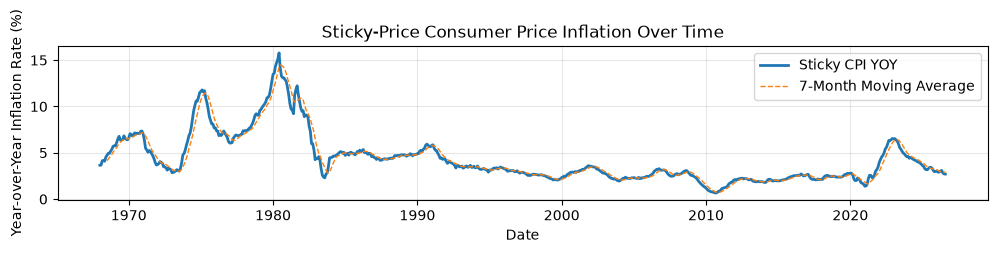

In [29]:
# lets view the whole dataset

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))

plt.plot(
    cpi_table["date"],
    cpi_table["value"],
    linewidth=2,
    label="Sticky CPI YOY"

)

plt.plot(
    cpi_table["date"],
    cpi_table["7ma"],
    linewidth=1,
    linestyle="--",
    label="7-Month Moving Average"
)

plt.title("Sticky-Price Consumer Price Inflation Over Time")
plt.xlabel("Date")
plt.ylabel("Year-over-Year Inflation Rate (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Moving Average notes** - The 7 month MA is mostly in line with the data in this big picture scale, there are only a few periods that you can see a clear seperation from the monthly data, those being when CPI had a very shrpe surge 

### **Next analysis** - Cool-off speed:

From this, we can see around **3–4 major surges in inflation**, followed by cool-offs.

The peaks seem to be around:

* **1967** — This one stayed near the peak for longer before cooling. I will ignore this one for our analysis.
* **1974**
* **1981**
* **2022**

I want to compare the **speed of the cool-down after each peak was reached**.

This is a rough analysis because I am not creating a strict rule for what is considered a surge in inflation or what is considered a cool-off. I am basing it on visually inspecting the chart above.

### For a deeper analysis, we could create rules such as:

* A **surge in inflation** is six months of higher highs, with inflation increasing by more than 100%.
* A **cool-off begins** when inflation has six months of lower lows.
* A **cool-off ends** when inflation has three months of higher highs after the cool-off has begun.


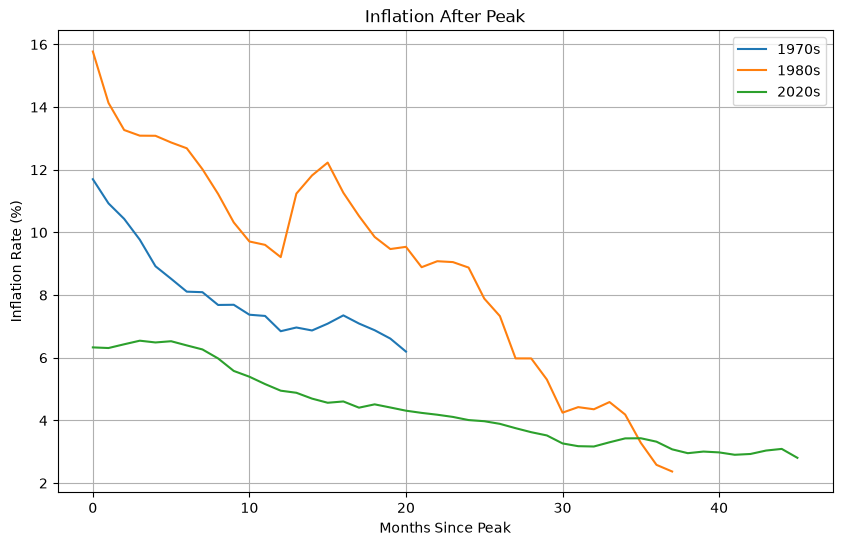

In [30]:


import matplotlib.pyplot as plt

 # I found out the aproximate peak and through dates for inflation in each of my target cycles, I let the latest cycle play out longer
target_ranges = {
    "1970s": ("1975-04-01", "1976-12-01"),
    "1980s": ("1980-06-01", "1983-07-01"),
    "2020s": ("2022-09-01", "2026-06-01")
}

plt.figure(figsize=(10, 6))

for name, (start, end) in target_ranges.items():

    # Get only data inside this range
    period = cpi_table[
        (cpi_table["date"] >= start) &
        (cpi_table["date"] <= end)
    ].copy()

    # Standardized x-axis to start from 0 instead of the datetime
    period["month"] = range(len(period))

    plt.plot(period["month"], period["value"], label=name)

plt.xlabel("Months Since Peak")
plt.ylabel("Inflation Rate (%)")
plt.title("Inflation After Peak")
plt.legend()
plt.grid(True)

plt.show()

    

* From this chart, you can see that inflation peaked at the lowest level of all three peaks I chose to analyze.
* Also, the cool-off is much more tame this time around, with around a 33% cool-off in 20 months, compared with 50% in the 1970s and somewhere near 40% in the 1980s.
* Also, this time we avoided the relatively small uptick in inflation that happened the other two times between the 10th and 20th months.
